# **1. Environment Setup**

In [1]:
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import numpy as np
import math
import os

I0000 00:00:1774556177.853962  423651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774556177.876707  423651 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774556178.381137  423651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## **1.1. Configure Default Paths**

In [2]:
MODELS_DIR = "models/"

In [3]:
if not os.path.exists(MODELS_DIR):
    os.mkdir(MODELS_DIR)

In [4]:
# Define paths to model files

MODEL_TF = MODELS_DIR + "model"
MODEL_NO_QUANT_TFLITE = MODELS_DIR + "model_no_quant.tflite"
MODEL_TFLITE = MODELS_DIR + "model.tflite"
MODEL_TFLITE_MICRO = MODELS_DIR + "model.cc"

## **1.2. Configure Random Seeds**

In [5]:
seed = 1

tf.random.set_seed(seed)
np.random.seed(seed)

# **2. Dataset Construction**

## **2.1. Data Generation**

In [6]:
# Number of sample datapoints

NUM_SAMPLES = 1000

In [7]:
# Generate a uniformly distributed set of random numbers in the range from
# 0 to 2π, which covers a complete sine wave oscillation

x_values = np.random.uniform(low = 0, high = 2 * math.pi, size = NUM_SAMPLES)

In [8]:
# Shuffle the values to guarantee they are not in order

np.random.shuffle(x_values)

In [9]:
# Calculate the corresponding sine values

y_values = np.sin(x_values).astype(np.float32)

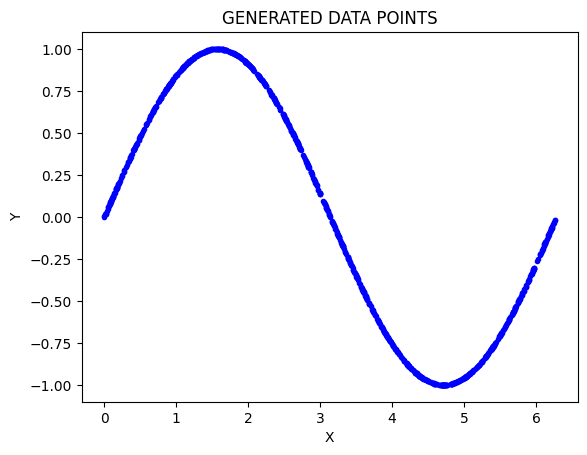

In [10]:
# Plot the data using blue dots

plt.plot(x_values, y_values, "b.")

plt.title("GENERATED DATA POINTS")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

## **2.2. Adding Noise**

In [11]:
# Add a small random number to each y value

y_values += 0.1 * np.random.randn(*y_values.shape)

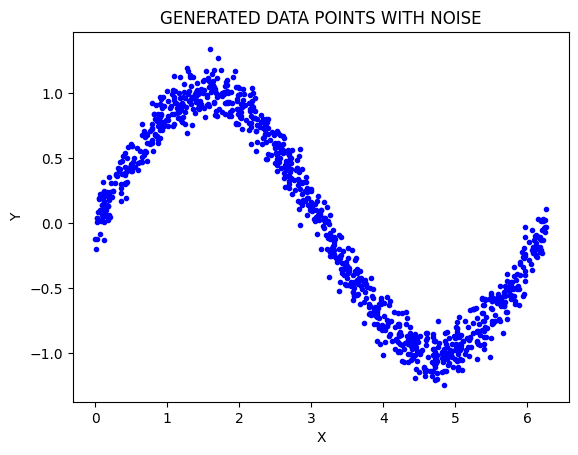

In [12]:
# Plot the data using blue dots

plt.plot(x_values, y_values, "b.")

plt.title("GENERATED DATA POINTS WITH NOISE")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

## **2.3. Split the Data**

In [13]:
# 60% of the data for training and 20% for testing. The remaining 20%
# will be used for validation

TRAIN_SPLIT =  int(0.6 * NUM_SAMPLES)
TEST_SPLIT = int(0.2 * NUM_SAMPLES + TRAIN_SPLIT)

In [14]:
# Chop the data into train, test and validation sets using the indices

x_train, x_test, x_validate = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])

In [15]:
# Double check that the splits add up correctly

assert (x_train.size + x_validate.size + x_test.size) ==  NUM_SAMPLES

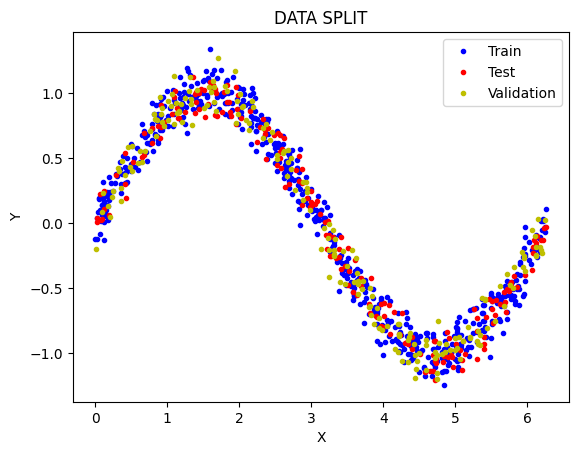

In [16]:
# Plot the data in each partition in different colors

plt.plot(x_train, y_train, "b.", label = "Train")
plt.plot(x_test, y_test, "r.", label = "Test")
plt.plot(x_validate, y_validate, "y.", label = "Validation")

plt.title("DATA SPLIT")

plt.xlabel("X")
plt.ylabel("Y")

plt.legend()

plt.show()

# **3. Model Training**

## **3.1. Design the Model**

In [17]:
# Use Keras to create a simple model architecture

model_1 = tf.keras.Sequential([

    # Define the input shape explicitly as an Input object
    # For a sine wave, we take a single scalar value as input
    keras.layers.Input(shape=(1,), name = "input_layer"), 
    
    # First layer with 8 neurons and "relu" activation function
    keras.layers.Dense(8, activation = "relu", name = "hidden_layer"),
    
    # Final layer is a single neuron to output a single predicted value
    keras.layers.Dense(1, name = "output_layer")
])

W0000 00:00:1774556192.317871  423883 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774556192.345968  423651 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [18]:
# Compile the model using the "adam" optimizer and "mse" loss function for regression

model_1.compile(
    optimizer = "adam", 
    loss = "mse", 
    metrics = ["mae"]
)

In [19]:
# Display the model"s architecture

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

## **3.2. Train the Model**

In [20]:
# Train the model on the training data while validating on the validation set

history_1 = model_1.fit(x_train, y_train, epochs = 500, batch_size = 64, validation_data = (x_validate, y_validate))

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5817 - mae: 0.6822 - val_loss: 0.5868 - val_mae: 0.6958
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5411 - mae: 0.6575 - val_loss: 0.5502 - val_mae: 0.6696
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5105 - mae: 0.6375 - val_loss: 0.5225 - val_mae: 0.6476
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4875 - mae: 0.6206 - val_loss: 0.5014 - val_mae: 0.6297
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4697 - mae: 0.6067 - val_loss: 0.4846 - val_mae: 0.6144
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4553 - mae: 0.5947 - val_loss: 0.4706 - val_mae: 0.6018
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4431 - mae: 0.5843 - val_loss: 0.4586 - val_mae: 0.5921
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4324 - mae: 0.5750 - val_loss: 0.4478 - val_mae: 0.5842
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.422

## **3.3. Plot Training Metrics**

### **3.3.1. Loss (MSE)**

In [21]:
# Draw a graph of the loss

train_loss = history_1.history["loss"]
val_loss = history_1.history["val_loss"]

epochs = range(1, len(train_loss) + 1)

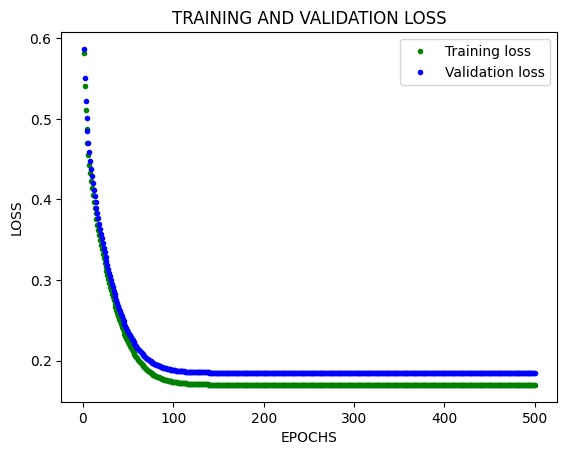

In [22]:
plt.plot(epochs, train_loss, "g.", label = "Training loss")
plt.plot(epochs, val_loss, "b.", label="Validation loss")

plt.title("TRAINING AND VALIDATION LOSS")
plt.xlabel("EPOCHS")
plt.ylabel("LOSS")

plt.legend()

plt.show()

In [23]:
# Exclude the first few epochs so the graph is easier to read

SKIP = 50

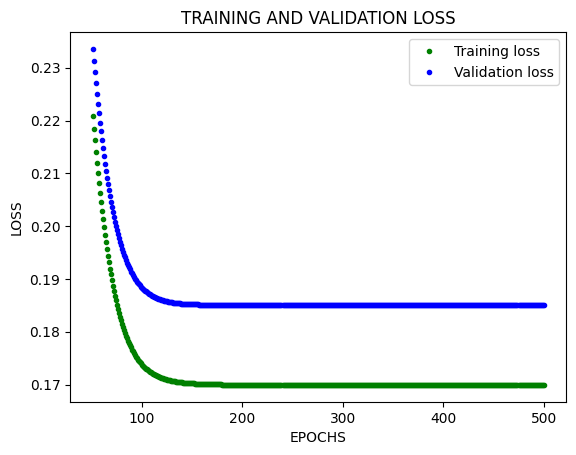

In [24]:
plt.plot(epochs[SKIP:], train_loss[SKIP:], "g.", label = "Training loss")
plt.plot(epochs[SKIP:], val_loss[SKIP:], "b.", label = "Validation loss")

plt.title("TRAINING AND VALIDATION LOSS")
plt.xlabel("EPOCHS")
plt.ylabel("LOSS")

plt.legend()

plt.show()

### **3.3.2. Mean Absolute Error (MAE)**

In [25]:
# Draw a graph of mean absolute error, which is another way of
# measuring the amount of error in the prediction

train_mae = history_1.history["mae"]
val_mae = history_1.history["val_mae"]

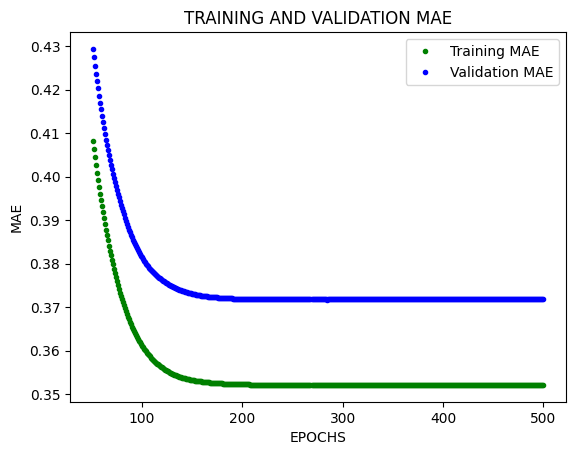

In [26]:
plt.plot(epochs[SKIP:], train_mae[SKIP:], "g.", label = "Training MAE")
plt.plot(epochs[SKIP:], val_mae[SKIP:], "b.", label = "Validation MAE")

plt.title("TRAINING AND VALIDATION MAE")
plt.xlabel("EPOCHS")
plt.ylabel("MAE")

plt.legend()

plt.show()

### **3.3.3. Actual vs Predicted Output**

In [27]:
# Calculate and print the loss on the test dataset
test_loss, test_mae = model_1.evaluate(x_test, y_test)

# Make predictions based on the test dataset
y_test_pred = model_1.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1629 - mae: 0.3452 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


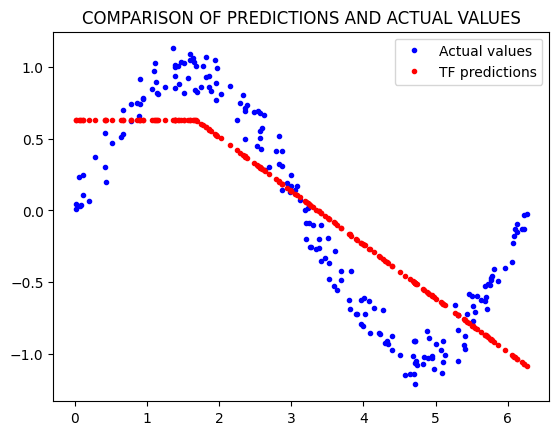

In [28]:
# Graph the predictions against the actual values

plt.plot(x_test, y_test, "b.", label = "Actual values")
plt.plot(x_test, y_test_pred, "r.", label = "TF predictions")

plt.title("COMPARISON OF PREDICTIONS AND ACTUAL VALUES")

plt.legend()

plt.show()

# **4. Training a Larger Model**

## **4.1. Design the Model**

In [29]:
# Use Keras to create a simple model architecture

model_2 = tf.keras.Sequential([

    # Define the input shape explicitly as an Input object
    # For a sine wave, we take a single scalar value as input
    keras.layers.Input(shape=(1,), name = "input_layer"), 
    
    # First layer with 16 neurons and "relu" activation function
    keras.layers.Dense(16, activation = "relu", name = "hidden_layer_1"),

    # Second layer with 16 neurons and "relu" activation function
    keras.layers.Dense(16, activation = "relu", name = "hidden_layer_2"),
    
    # Final layer is a single neuron to output a single predicted value
    keras.layers.Dense(1, name = "output_layer")
])

In [30]:
# Compile the model using the "adam" optimizer and "mse" loss function for regression

model_2.compile(
    optimizer = "adam", 
    loss = "mse", 
    metrics = ["mae"]
)

In [31]:
# Display the model"s architecture

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

## **4.2. Train the Model**

In [32]:
# Train the model on the training data while validating on the validation set

history_2 = model_2.fit(x_train, y_train, epochs = 500, batch_size = 64, validation_data = (x_validate, y_validate))

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1461 - mae: 0.9118 - val_loss: 0.9571 - val_mae: 0.8722
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7865 - mae: 0.7866 - val_loss: 0.6804 - val_mae: 0.7542
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5825 - mae: 0.6849 - val_loss: 0.5447 - val_mae: 0.6611
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4953 - mae: 0.6223 - val_loss: 0.4961 - val_mae: 0.6115
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4670 - mae: 0.5914 - val_loss: 0.4783 - val_mae: 0.5953
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4531 - mae: 0.5759 - val_loss: 0.4639 - val_mae: 0.5861
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4386 - mae: 0.5666 - val_loss: 0.4481 - val_mae: 0.5774
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4206 - mae: 0.5575 - val_loss: 0.4306 - val_mae: 0.5687
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.405

## **4.3. Plot Training Metrics**

### **4.3.1. Loss (MSE)**

In [33]:
# Draw a graph of the loss

train_loss = history_2.history["loss"]
val_loss = history_2.history["val_loss"]

epochs = range(1, len(train_loss) + 1)

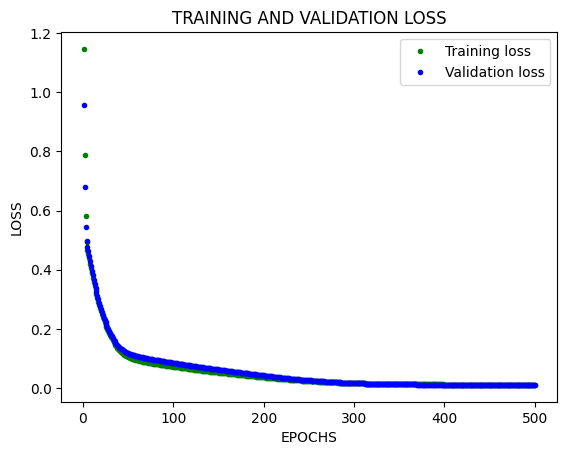

In [34]:
plt.plot(epochs, train_loss, "g.", label = "Training loss")
plt.plot(epochs, val_loss, "b.", label="Validation loss")

plt.title("TRAINING AND VALIDATION LOSS")
plt.xlabel("EPOCHS")
plt.ylabel("LOSS")

plt.legend()

plt.show()

In [35]:
# Exclude the first few epochs so the graph is easier to read

SKIP = 50

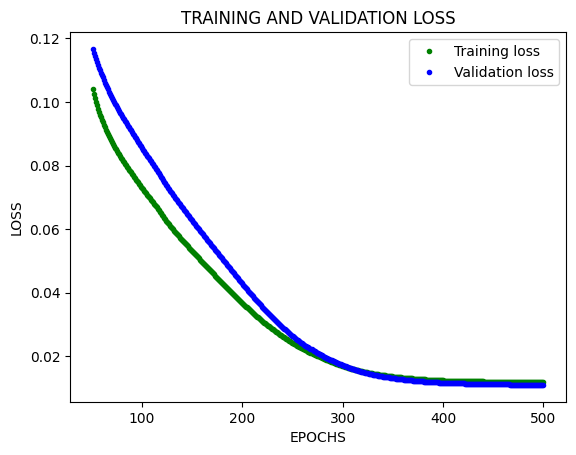

In [36]:
plt.plot(epochs[SKIP:], train_loss[SKIP:], "g.", label = "Training loss")
plt.plot(epochs[SKIP:], val_loss[SKIP:], "b.", label = "Validation loss")

plt.title("TRAINING AND VALIDATION LOSS")
plt.xlabel("EPOCHS")
plt.ylabel("LOSS")

plt.legend()

plt.show()

### **4.3.2. Mean Absolute Error (MAE)**

In [37]:
# Draw a graph of mean absolute error, which is another way of
# measuring the amount of error in the prediction

train_mae = history_2.history["mae"]
val_mae = history_2.history["val_mae"]

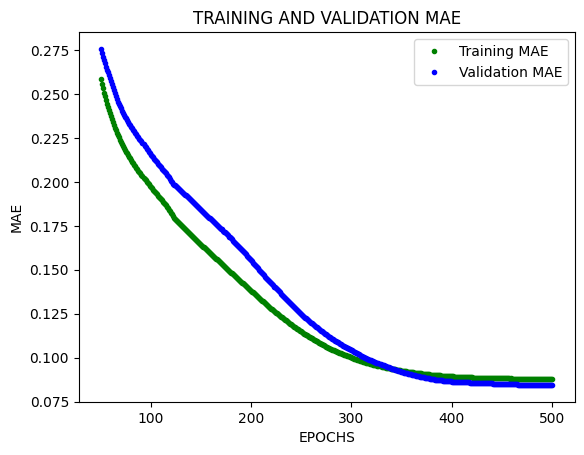

In [38]:
plt.plot(epochs[SKIP:], train_mae[SKIP:], "g.", label = "Training MAE")
plt.plot(epochs[SKIP:], val_mae[SKIP:], "b.", label = "Validation MAE")

plt.title("TRAINING AND VALIDATION MAE")
plt.xlabel("EPOCHS")
plt.ylabel("MAE")

plt.legend()

plt.show()

### **4.3.3. Actual vs Predicted Output**

In [39]:
# Calculate and print the loss on the test dataset
test_loss, test_mae = model_2.evaluate(x_test, y_test)

# Make predictions based on the test dataset
y_test_pred = model_2.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0106 - mae: 0.0818 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


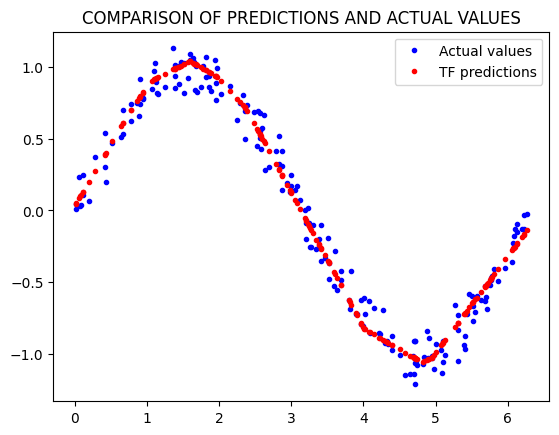

In [40]:
# Graph the predictions against the actual values

plt.plot(x_test, y_test, "b.", label = "Actual values")
plt.plot(x_test, y_test_pred, "r.", label = "TF predictions")

plt.title("COMPARISON OF PREDICTIONS AND ACTUAL VALUES")

plt.legend()

plt.show()

In [41]:
# Save the best model (model 2) to disk
model_2.export(MODEL_TF)

INFO:tensorflow:Assets written to: models/model/assets


INFO:tensorflow:Assets written to: models/model/assets


Saved artifact at 'models/model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  125687524382800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125687524383760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125687524383568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125687524384144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125687524383952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125687524384528: TensorSpec(shape=(), dtype=tf.resource, name=None)


# **5. Generate a TensorFlow Lite Model**

## **5.1. Generate Models with or without Quantization**

In [42]:
# Convert the model to the TensorFlow Lite format without quantization

converter = tf.lite.TFLiteConverter.from_saved_model(MODEL_TF)
model_no_quant_tflite = converter.convert()

W0000 00:00:1774556274.191586  423651 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774556274.191608  423651 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774556274.191815  423651 reader.cc:83] Reading SavedModel from: models/model
I0000 00:00:1774556274.192073  423651 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774556274.192078  423651 reader.cc:147] Reading SavedModel debug info (if present) from: models/model
I0000 00:00:1774556274.194064  423651 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1774556274.194575  423651 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774556274.209001  423651 loader.cc:220] Running initialization op on SavedModel bundle at path: models/model
I0000 00:00:1774556274.213195  423651 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 21385 microseconds.
I0000 00:00:1774556274.219009  423651 dump_mlir_u

In [43]:
# Save the model to disk

open(MODEL_NO_QUANT_TFLITE, "wb").write(model_no_quant_tflite)

3384

In [44]:
# Convert the model to the TensorFlow Lite format with quantization

def representative_dataset():
  for i in range(500):
    yield([x_train[i].reshape(1, 1).astype(np.float32)])

In [45]:
# Set the optimization flag

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Enforce integer only quantization

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Provide a representative dataset to ensure we quantize correctly

converter.representative_dataset = representative_dataset
model_tflite = converter.convert()

W0000 00:00:1774556286.055056  423651 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774556286.055074  423651 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774556286.055184  423651 reader.cc:83] Reading SavedModel from: models/model
I0000 00:00:1774556286.055430  423651 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774556286.055435  423651 reader.cc:147] Reading SavedModel debug info (if present) from: models/model
I0000 00:00:1774556286.057444  423651 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774556286.070312  423651 loader.cc:220] Running initialization op on SavedModel bundle at path: models/model
I0000 00:00:1774556286.074028  423651 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 18849 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1774556286.107428  423651 flatbuffer_export.cc:3851] 

In [46]:
# Save the model to disk
open(MODEL_TFLITE, "wb").write(model_tflite)

3952

## **5.2. Compare Model Performance**

In [60]:
def predict_tflite(tflite_model, x_test):
  # Prepare the test data
  x_test_ = x_test.copy()
  x_test_ = x_test_.reshape((x_test.size, 1))
  x_test_ = x_test_.astype(np.float32)

  # Initialize the TFLite interpreter
  interpreter = tf.lite.Interpreter(model_content=tflite_model,
                                    experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_REF)
  interpreter.allocate_tensors()

  input_details = interpreter.get_input_details()[0]
  output_details = interpreter.get_output_details()[0]

  # If required, quantize the input layer (from float to integer)
  input_scale, input_zero_point = input_details["quantization"]
  if (input_scale, input_zero_point) != (0.0, 0):
    x_test_ = x_test_ / input_scale + input_zero_point
    x_test_ = x_test_.astype(input_details["dtype"])
  
  # Invoke the interpreter
  y_pred = np.empty(x_test_.size, dtype=output_details["dtype"])
  for i in range(len(x_test_)):
    interpreter.set_tensor(input_details["index"], [x_test_[i]])
    interpreter.invoke()
    y_pred[i] = interpreter.get_tensor(output_details["index"])[0][0]
  
  # If required, dequantized the output layer (from integer to float)
  output_scale, output_zero_point = output_details["quantization"]
  if (output_scale, output_zero_point) != (0.0, 0):
    y_pred = y_pred.astype(np.float32)
    y_pred = (y_pred - output_zero_point) * output_scale

  return y_pred

def evaluate_tflite(tflite_model, x_test, y_true):
  global model_2
  y_pred = predict_tflite(tflite_model, x_test)
  loss_function = tf.keras.losses.get(model_2.loss)
  loss = loss_function(y_true, y_pred).numpy()
  return loss

### **5.2.1. Predictions**

In [61]:
# Calculate predictions
y_test_pred_tf = model_2.predict(x_test)
y_test_pred_no_quant_tflite = predict_tflite(model_no_quant_tflite, x_test)
y_test_pred_tflite = predict_tflite(model_tflite, x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/home/nico/Desktop/TinyML/sine-wave/env/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


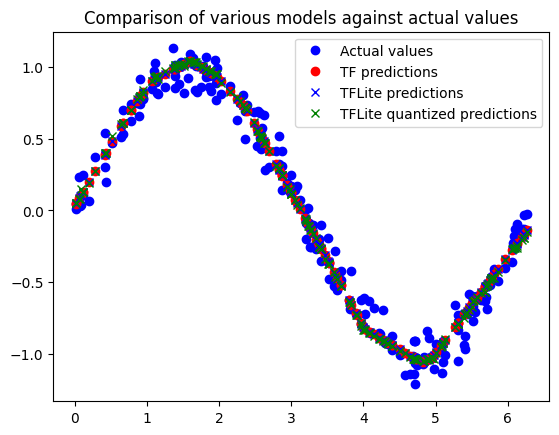

In [62]:
# Compare predictions
plt.clf()
plt.title('Comparison of various models against actual values')
plt.plot(x_test, y_test, 'bo', label='Actual values')
plt.plot(x_test, y_test_pred_tf, 'ro', label='TF predictions')
plt.plot(x_test, y_test_pred_no_quant_tflite, 'bx', label='TFLite predictions')
plt.plot(x_test, y_test_pred_tflite, 'gx', label='TFLite quantized predictions')
plt.legend()
plt.show()

### **5.2.2. Loss (MSE)**

In [65]:
import pandas as pd

In [66]:
# Calculate loss
loss_tf, _ = model_2.evaluate(x_test, y_test, verbose=0)
loss_no_quant_tflite = evaluate_tflite(model_no_quant_tflite, x_test, y_test)
loss_tflite = evaluate_tflite(model_tflite, x_test, y_test)

/home/nico/Desktop/TinyML/sine-wave/env/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [67]:
# Compare loss
df = pd.DataFrame.from_records(
    [["TensorFlow", loss_tf],
     ["TensorFlow Lite", loss_no_quant_tflite],
     ["TensorFlow Lite Quantized", loss_tflite]],
     columns = ["Model", "Loss/MSE"], index="Model").round(4)
df

,Loss/MSE
Model,
TensorFlow,0.0106
TensorFlow Lite,0.0106
TensorFlow Lite Quantized,0.0109


In [68]:
# Calculate size
size_tf = os.path.getsize(MODEL_TF)
size_no_quant_tflite = os.path.getsize(MODEL_NO_QUANT_TFLITE)
size_tflite = os.path.getsize(MODEL_TFLITE)

In [69]:
# Compare size
pd.DataFrame.from_records(
    [["TensorFlow", f"{size_tf} bytes", ""],
     ["TensorFlow Lite", f"{size_no_quant_tflite} bytes ", f"(reduced by {size_tf - size_no_quant_tflite} bytes)"],
     ["TensorFlow Lite Quantized", f"{size_tflite} bytes", f"(reduced by {size_no_quant_tflite - size_tflite} bytes)"]],
     columns = ["Model", "Size", ""], index="Model")

,Size,
Model,,
TensorFlow,4096 bytes,
TensorFlow Lite,3384 bytes,(reduced by 712 bytes)
TensorFlow Lite Quantized,3952 bytes,(reduced by -568 bytes)
